In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv


In [4]:
load_dotenv()
data_dir = Path(os.getenv('DATA_FILE_DIR'))

In [5]:
df = pd.read_csv(data_dir / 'log_clean.csv', parse_dates=['datetime'])

In [6]:
df.head()

,ip_address,datetime,request_type,endpoint,http_version,status_code,user_agent,country,countryCode,region,regionName,city,zip,lat,lon,timezone
0,129.146.237.0,2026-07-12 11:11:43+00:00,GET,/blog/0,HTTP/1.1,200,Scrapy/2.16.0 (+https://scrapy.org),United States,US,AZ,Arizona,Phoenix,85008,33.465600,-111.99560,America/Phoenix
1,47.82.11.184,2026-07-12 11:12:52+00:00,GET,/sitemap_news.xml.gz,HTTP/1.1,404,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,Singapore,SG,03,North West,Singapore,858877,1.352080,103.82000,Asia/Singapore
2,40.77.167.144,2026-07-12 11:20:49+00:00,GET,/,HTTP/1.1,200,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",United States,US,VA,Virginia,Boydton,23917,36.677696,-78.37471,America/New_York
3,17.241.227.225,2026-07-12 11:26:03+00:00,GET,/photos/france,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,United States,US,CA,California,Cupertino,95014,37.332200,-122.01100,America/Los_Angeles
4,154.159.252.207,2026-07-12 12:02:19+00:00,GET,/photos/australia,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10) ...,Kenya,KE,30,Nairobi County,Nairobi,09831,-1.284100,36.81550,Africa/Nairobi


In [7]:
df.groupby('countryCode')['ip_address'].count().sort_values()

countryCode
AL      1
BG      1
CG      1
BO      1
CM      1
     ... 
FR     35
GB     39
SG     47
DE     64
US    640
Name: ip_address, Length: 80, dtype: int64

In [8]:
min_date = df['datetime'].min().strftime("%Y-%m-%d")
max_date = df['datetime'].max().strftime("%Y-%m-%d")

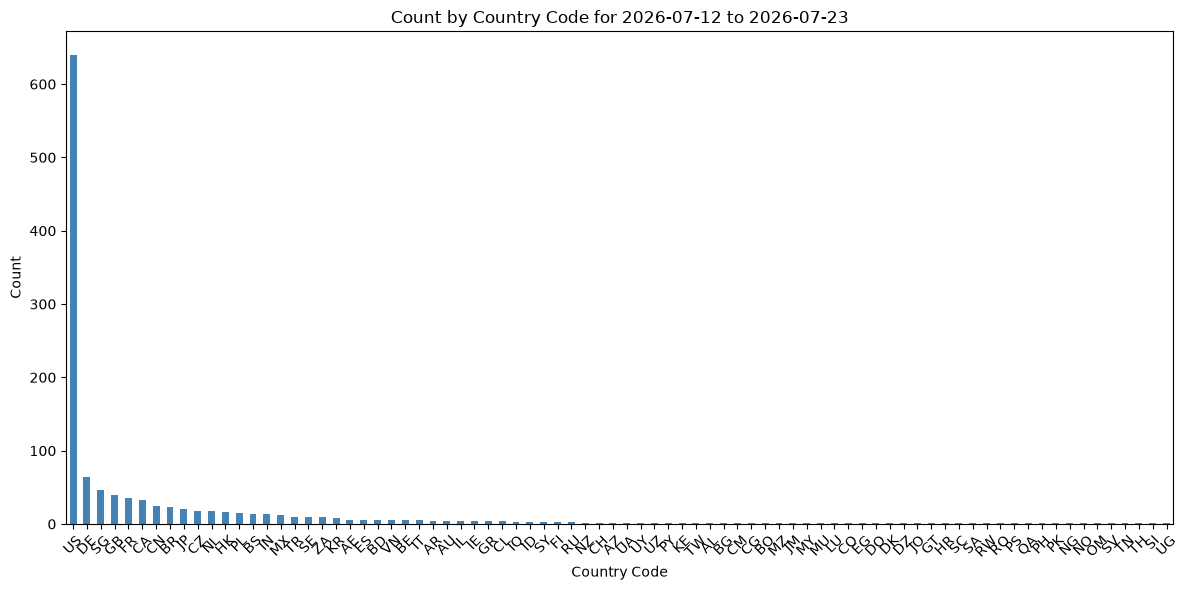

In [9]:
counts = df.groupby('countryCode')['ip_address'].count().sort_values(ascending=False)

counts.plot(kind='bar', figsize=(12, 6), color='steelblue')
plt.title(f'Count by Country Code for {min_date} to {max_date}')
plt.xlabel('Country Code')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

In [10]:
df.groupby('endpoint')['ip_address'].count().sort_values()

endpoint
/blog/Figure%201                                                 1
/blog/Figure%205                                                 1
/blog/Figure%204                                                 1
/codisto-sync/test                                               1
/blog/Figure%206                                                 1
/blog/Figure%202                                                 1
/wp-admin/install.php                                            1
/wp-admin/admin-ajax.php?action=ai1wm_status                     1
/static/images/Compute-Power.png                                 1
/static/images/Data-Center-Energy-Use.png                        1
/static/images/Power-Composite.png                               1
/sites/favicon.png                                               1
/sitemap_news.xml.gz                                             1
/sites/favicon.ico                                               1
/sitemap-index.xml                                   

In [12]:
df_filtered = df.loc[df['endpoint'] == '/blog/4']

In [13]:
df_filtered

,ip_address,datetime,request_type,endpoint,http_version,status_code,user_agent,country,countryCode,region,regionName,city,zip,lat,lon,timezone
13,102.141.42.74,2026-07-12 17:57:09+00:00,GET,/blog/4,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,Congo Republic,CG,BZV,Brazzaville,Brazzaville,NaN,-4.256800,15.28720,Africa/Brazzaville
50,52.167.144.142,2026-07-13 09:33:36+00:00,GET,/blog/4,HTTP/1.1,200,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",United States,US,VA,Virginia,Boydton,23917,36.677696,-78.37471,America/New_York
91,20.194.1.8,2026-07-14 08:39:31+00:00,GET,/blog/4,HTTP/1.1,200,"Mozilla/5.0 AppleWebKit/537.36 (KHTML, like Ge...",South Korea,KR,11,Seoul,Seoul,06181,37.566500,126.97800,Asia/Seoul
112,34.96.60.165,2026-07-14 22:11:21+00:00,GET,/blog/4,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,United States,US,IA,Iowa,Council Bluffs,NaN,41.261900,-95.86080,America/Chicago
119,54.39.203.84,2026-07-15 03:52:58+00:00,GET,/blog/4,HTTP/1.1,200,Mozilla/5.0 (compatible; AhrefsBot/7.0; +http:...,Canada,CA,QC,Quebec,Beauharnois,J6N,45.316100,-73.87360,America/Toronto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1158,142.111.59.144,2026-07-22 13:18:47+00:00,GET,/blog/4,HTTP/1.1,200,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,United States,US,UT,Utah,Orem,84097,40.303200,-111.67500,America/Denver
1173,27.152.183.246,2026-07-23 05:29:18+00:00,GET,/blog/4,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 12_0_0)...,China,CN,FJ,Fujian,Wenquan,NaN,26.099800,119.29700,Asia/Shanghai
1174,143.202.210.215,2026-07-23 05:29:26+00:00,GET,/blog/4,HTTP/1.1,200,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,Paraguay,PY,10,Alto Paraná Department,Ciudad del Este,NaN,-25.503600,-54.65070,America/Asuncion
1175,60.163.52.221,2026-07-23 05:29:27+00:00,GET,/blog/4,HTTP/1.1,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 12_0_0)...,China,CN,ZJ,Zhejiang,Shaoxing,NaN,30.003400,120.56760,Asia/Shanghai


In [14]:
df_404 = df.loc[df['status_code'] == 404]

In [15]:
df_404

,ip_address,datetime,request_type,endpoint,http_version,status_code,user_agent,country,countryCode,region,regionName,city,zip,lat,lon,timezone
1,47.82.11.184,2026-07-12 11:12:52+00:00,GET,/sitemap_news.xml.gz,HTTP/1.1,404,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,Singapore,SG,03,North West,Singapore,858877,1.35208,103.82000,Asia/Singapore
18,47.82.11.88,2026-07-12 18:38:58+00:00,GET,/sitemap-index.xml,HTTP/1.1,404,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,Singapore,SG,03,North West,Singapore,858877,1.35208,103.82000,Asia/Singapore
40,140.248.75.88,2026-07-13 04:24:38+00:00,GET,/.git/config,HTTP/1.1,404,git/2.39.2,Germany,DE,HE,Hesse,Frankfurt am Main,60313,50.11690,8.68370,Europe/Berlin
41,140.248.75.88,2026-07-13 04:24:38+00:00,GET,/.git/HEAD,HTTP/1.1,404,git/2.39.2,Germany,DE,HE,Hesse,Frankfurt am Main,60313,50.11690,8.68370,Europe/Berlin
726,144.172.98.123,2026-07-16 15:35:41+00:00,GET,/.git/config,HTTP/1.1,404,Mozilla/5.0 (X11; Linux x86_64),United States,US,NY,New York,Staten Island,10311,40.60630,-74.17740,America/New_York
924,195.63.31.229,2026-07-18 14:37:37+00:00,GET,/news-sitemap.xml,HTTP/1.1,404,Mozilla/5.0,Germany,DE,BE,State of Berlin,Berlin,10178,52.51960,13.40690,Europe/Berlin
926,216.26.255.238,2026-07-18 14:37:39+00:00,GET,/wp-sitemap.xml,HTTP/1.1,404,Mozilla/5.0,France,FR,IDF,Île-de-France,Paris,75001,48.85580,2.34940,Europe/Paris
927,104.207.56.97,2026-07-18 14:37:45+00:00,GET,/sitemap.xml.gz,HTTP/1.1,404,Mozilla/5.0,Germany,DE,BE,State of Berlin,Berlin,10178,52.51960,13.40690,Europe/Berlin
928,45.3.41.185,2026-07-18 14:37:47+00:00,GET,/sitemap.xml.gz,HTTP/1.1,404,Mozilla/5.0,Brazil,BR,SP,São Paulo,São Paulo,01000,-23.54750,-46.63610,America/Sao_Paulo
929,104.207.44.14,2026-07-18 14:37:49+00:00,GET,/wp-sitemap.xml,HTTP/1.1,404,Mozilla/5.0,United States,US,VA,Virginia,Ashburn,20149,39.04690,-77.49030,America/New_York
